In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
leaderboard = pd.DataFrame([
    {
        "Model": "Random Forest",
        "MAE": 1.1706329113924052,
        "RMSE": 1.97473322451841,
        "R2": 0.8098238322966482
    },
    {
        "Model": "Gradient Boosting",
        "MAE": 1.267622292850229,
        "RMSE": 2.154159988807915,
        "R2": 0.7736944862054645
    },
    {
        "Model": "Extra Trees",
        "MAE": 1.3311814345991562,
        "RMSE": 2.2644825354383293,
        "R2": 0.7499210274296113
    },
    {
        "Model": "Decision Tree",
        "MAE": 1.357218203737191,
        "RMSE": 2.467248497769575,
        "R2": 0.7031308891822728
    },
    {
        "Model": "SVR",
        "MAE": 1.8366678536589514,
        "RMSE": 2.7260297218073055,
        "R2": 0.6375898115704413
    },
    {
        "Model": "MLP Regressor",
        "MAE": 2.020337290519022,
        "RMSE": 2.784599125864401,
        "R2": 0.6218495773067232
    },
    {
        "Model": "KNN",
        "MAE": 2.5848101265822785,
        "RMSE": 3.3926950565642415,
        "R2": 0.4386562685587473
    }
])

print("Leaderboard created.")
print("Models:", len(leaderboard))

Leaderboard created.
Models: 7


In [3]:
leaderboard = leaderboard.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

leaderboard["Rank"] = range(
    1,
    len(leaderboard) + 1
)

leaderboard

,Model,MAE,RMSE,R2,Rank
0,Random Forest,1.170633,1.974733,0.809824,1
1,Gradient Boosting,1.267622,2.154160,0.773694,2
2,Extra Trees,1.331181,2.264483,0.749921,3
3,Decision Tree,1.357218,2.467248,0.703131,4
4,SVR,1.836668,2.726030,0.637590,5
5,MLP Regressor,2.020337,2.784599,0.621850,6
6,KNN,2.584810,3.392695,0.438656,7


In [4]:
winner = leaderboard.iloc[0]

winner_name = str(
    winner["Model"]
)

winner_rmse = float(
    winner["RMSE"]
)

print("Regression Winner")
print("-----------------")
print(f"Model: {winner_name}")
print(f"RMSE: {winner_rmse:.4f}")

Regression Winner
-----------------
Model: Random Forest
RMSE: 1.9747


In [5]:
leaderboard["RMSE Difference from Winner"] = (
    leaderboard["RMSE"]
    - winner_rmse
)

leaderboard["Percentage Difference"] = (
    leaderboard["RMSE Difference from Winner"]
    / winner_rmse
    * 100
)

leaderboard.round(4)

,Model,MAE,RMSE,R2,Rank,RMSE Difference from Winner,Percentage Difference
0,Random Forest,1.1706,1.9747,0.8098,1,0.0000,0.0000
1,Gradient Boosting,1.2676,2.1542,0.7737,2,0.1794,9.0861
2,Extra Trees,1.3312,2.2645,0.7499,3,0.2897,14.6728
3,Decision Tree,1.3572,2.4672,0.7031,4,0.4925,24.9409
4,SVR,1.8367,2.7260,0.6376,5,0.7513,38.0455
5,MLP Regressor,2.0203,2.7846,0.6218,6,0.8099,41.0114
6,KNN,2.5848,3.3927,0.4387,7,1.4180,71.8052


In [6]:
top_three = leaderboard.head(3)

top_three[
    [
        "Model",
        "RMSE",
        "RMSE Difference from Winner",
        "Percentage Difference"
    ]
].round(4)

,Model,RMSE,RMSE Difference from Winner,Percentage Difference
0,Random Forest,1.9747,0.0000,0.0000
1,Gradient Boosting,2.1542,0.1794,9.0861
2,Extra Trees,2.2645,0.2897,14.6728


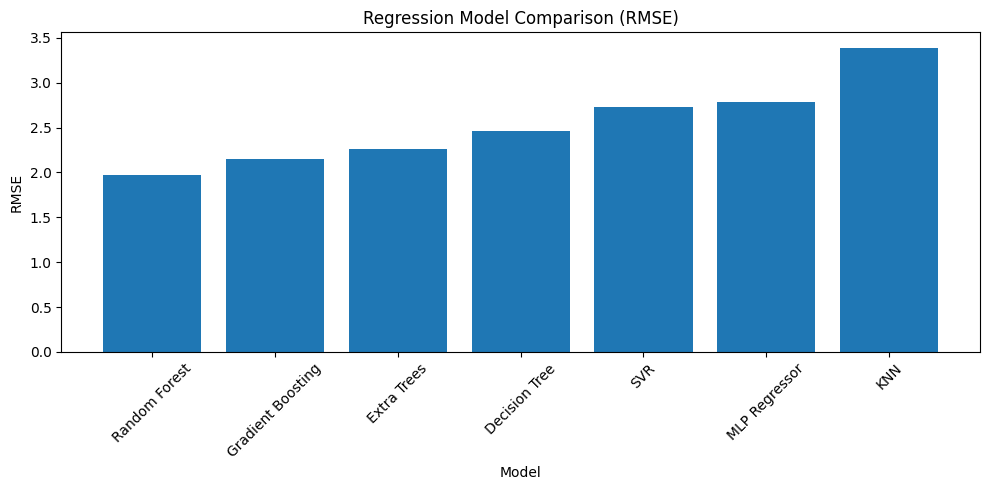

In [7]:
plt.figure(figsize=(10, 5))

plt.bar(
    leaderboard["Model"],
    leaderboard["RMSE"]
)

plt.title(
    "Regression Model Comparison (RMSE)"
)

plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [8]:
from pathlib import Path

figures_dir = Path("../figures")
figures_dir.mkdir(
    exist_ok=True
)

plt.figure(figsize=(10, 5))

plt.bar(
    leaderboard["Model"],
    leaderboard["RMSE"]
)

plt.title(
    "Regression Model Comparison (RMSE)"
)

plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    figures_dir / "regression_leaderboard_rmse.png",
    bbox_inches="tight"
)

plt.close()

print("Figure saved.")

Figure saved.


In [9]:
leaderboard.to_csv(
    "../reports/regression_leaderboard.csv",
    index=False
)

print(
    "Leaderboard exported."
)

Leaderboard exported.
